In [7]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import gridspec
import torch
from hydra import initialize_config_dir, compose

from configs.constants import *
from force_regression.utils.configuration import load_project_configuration, load_input_data_configuration, update_finger_ids
from force_regression.training.snn_pipeline import SnnMusDatasetPreparation
import force_regression.data.noise as noise_utils
from force_regression.data.noise import add_jitter
import force_regression.training.snn_pipeline as snn_prep
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import force_regression.utils.configuration as lrc


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load decomposed MUs

In [8]:
subject = 'S1'  # S1 | S2
exp_dir = 'flex'    # flex | ext
decoder_type = 'spiking' # spiking | leaky

## Prepare configurations

In [9]:
abs_config_dir=os.path.abspath("../../configs/hydra")
with initialize_config_dir(version_base=None, config_dir=abs_config_dir):
    cfg = compose(config_name="snn",
                  overrides=[f"decoder_type={decoder_type}",
                             f"task.exp_dir={exp_dir}",
                            "logging.wandb.use_wandb=False",
                             ]
                  )
    print(cfg)
flat_snn_config = lrc.flatten_hydra_config(cfg)


{'task': {'mvc': [15], 'subject': 'S1', 'exp_dir': 'flex', 'train_fing_id': [0, 1, 2, 3, 4], 'percent_omission': 0, 'percent_addition': 0, 'jitter_std': 0.005, 'percent_misattribution': 0, 'rand_indices_ratio': 0.1, 'noise_mode': None, 'segment_hold': False, 'select_dir': True, 'shuffle_fingers_seed': 10, 'split_rep': True, 'split_type': 'with_overlap', 'overlap_perc': 0.5}, 'decoder_type': {'topology': 'shallow_spiking_double_filter', 'lr': 0.001, 'use_file_data': False, 'use_inf_network': True, 'tau_syn': 0.01, 'tau_mem': 0.03, 'spk_threshold': 0.045, 'first_filter_tau': 0.05, 'second_filter_tau': 0.08, 'w_fixed_filt': 1, 'w_init_dist': 'uniform', 'w_init': [-0.01, 0.01], 'w_init_mean': 0, 'w_init_std': 0.005, 'bias_init': [-0.001, 0.001], 'learn_threshold': False, 'learn_tau_mem': True, 'learn_tau_syn': False, 'use_aleaky': False, 'threshold_tau_adapt': 0.1, 'threshold_scale_adapt': 1, 'post_process_filt': True, 'post_filt_cutoff': 2, 'post_filt_order': 4, 'log_ts_freq': 10}, 'loggi

In [10]:
config_path = os.path.join(project_dir, 'configs/config.json')
data_root_dir, results_root_dir, subject_name_encoding, wandb_entity = load_project_configuration(
        config_path)

data_config = load_input_data_configuration(flat_snn_config, data_root_dir,
                                            results_root_dir, flat_snn_config.segment_hold,
                                            subject_name_encoding)
output_figures_dir = os.path.join(data_config.root_results_dir, data_config.figs_dir)

mvcs_string = snn_prep.create_mvcs_string(data_config)

snn_config = snn_prep.create_wandb_config(flat_snn_config, wandb_entity) if flat_snn_config.use_wandb else flat_snn_config
# snn_config = update_finger_ids(data_config, snn_config)
print(f"Config from file: {snn_config}")

Config from file: namespace(mvc=[15], subject='S1', exp_dir='flex', train_fing_id=[0, 1, 2, 3, 4], percent_omission=0, percent_addition=0, jitter_std=0.005, percent_misattribution=0, rand_indices_ratio=0.1, noise_mode=None, segment_hold=False, select_dir=True, shuffle_fingers_seed=10, split_rep=True, split_type='with_overlap', overlap_perc=0.5, noise_torch_seed=100, torch_seed=90, train_rep_binwidth=10, inf_rep_binwidth=10, rep_on_rep='2on1', dt=0.01, train_with_cv=True, num_iter=100, train_batch_size=16, test_batch_size=1, topology='shallow_spiking_double_filter', lr=0.001, use_file_data=False, use_inf_network=True, tau_syn=0.01, tau_mem=0.03, spk_threshold=0.045, first_filter_tau=0.05, second_filter_tau=0.08, w_fixed_filt=1, w_init_dist='uniform', w_init=[-0.01, 0.01], w_init_mean=0, w_init_std=0.005, bias_init=[-0.001, 0.001], learn_threshold=False, learn_tau_mem=True, learn_tau_syn=False, use_aleaky=False, threshold_tau_adapt=0.1, threshold_scale_adapt=1, post_process_filt=True, po

In [11]:
print(f"Default training binwidth:{snn_config.train_rep_binwidth}")

Default training binwidth:10


## Load prepared MUs df

File Trap_0_15_1_1_3_20.mat loaded successfully with mat73
thumb | flex | start rep1 0.81240234375
---------------------------------------------
Found 1 units with abnormal firing rates.
Unit 12 fr rep 1: 0.00 Hz, fr rep 2: 2.86 Hz. Removing...
---------------------------------------------
---------------------------------------------
Found 6 units with abnormal firing rates.
Unit 7 fr rep 1: 2.36 Hz, fr rep 2: 0.21 Hz. Removing...
Unit 13 fr rep 1: 0.00 Hz, fr rep 2: 1.11 Hz. Removing...
Unit 14 fr rep 1: 0.00 Hz, fr rep 2: 2.00 Hz. Removing...
Unit 15 fr rep 1: 0.00 Hz, fr rep 2: 0.68 Hz. Removing...
Unit 16 fr rep 1: 0.00 Hz, fr rep 2: 2.07 Hz. Removing...
Unit 17 fr rep 1: 0.00 Hz, fr rep 2: 0.96 Hz. Removing...
---------------------------------------------
---------------------------------------------
Found 0 units with abnormal firing rates.


/Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/force_regression/data/handlers/mu_handler.py:183: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mu_df = pd.concat([mu_df, electrode_mu_df], ignore_index=True)


File Trap_0_-15_1_1_3_20.mat loaded successfully with mat73
thumb | ext | start rep1 1.06240234375
---------------------------------------------
Found 0 units with abnormal firing rates.
---------------------------------------------
Found 7 units with abnormal firing rates.
Unit 2 fr rep 1: 2.50 Hz, fr rep 2: 0.29 Hz. Removing...
Unit 10 fr rep 1: 1.61 Hz, fr rep 2: 0.68 Hz. Removing...
Unit 14 fr rep 1: 0.25 Hz, fr rep 2: 2.89 Hz. Removing...
Unit 17 fr rep 1: 0.04 Hz, fr rep 2: 2.46 Hz. Removing...
Unit 19 fr rep 1: 0.00 Hz, fr rep 2: 2.32 Hz. Removing...
Unit 21 fr rep 1: 0.00 Hz, fr rep 2: 3.96 Hz. Removing...
Unit 22 fr rep 1: 0.00 Hz, fr rep 2: 1.86 Hz. Removing...
---------------------------------------------
---------------------------------------------
Found 0 units with abnormal firing rates.
File Trap_0_15_2_1_3_20.mat loaded successfully with mat73
index | flex | start rep1 0.93740234375
---------------------------------------------
Found 0 units with abnormal firing rates.

/Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/force_regression/data/datasets.py:193: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/IndexingUtils.h:28.)
  spikes_for_finger[SP_TIME] = spikes_for_finger[SP_TIME].apply(lambda x: x[np.logical_and(x >= start_time_in_samples, x <= end_time_in_samples)] if len(x) > 0 else np.array([]))
/Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/force_regression/data/datasets.py:193: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spikes_for_finger[SP_TIME] = spikes_for_finger[SP_TIME].apply(lambda x: x[np.logical_and(x >= 

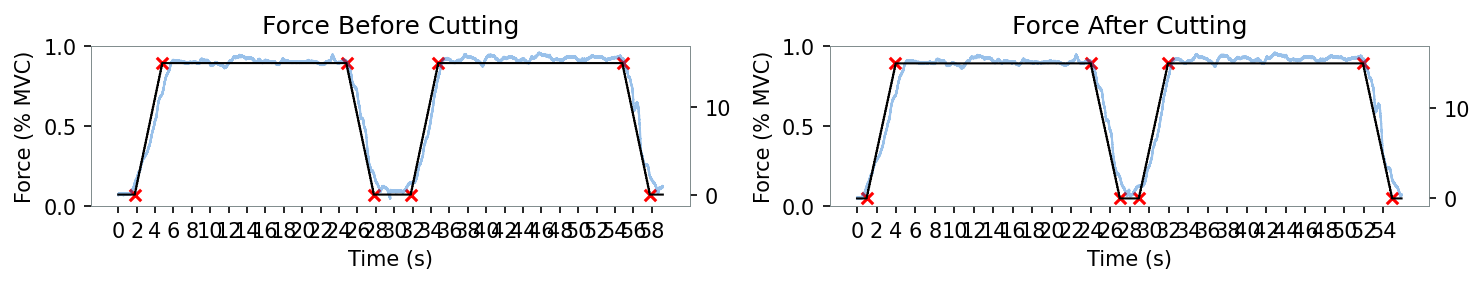

In [12]:
mu_df_sorted, force_df, data_config = snn_prep.load_mu_data_for_snn(data_config,
                                                                    flat_snn_config.use_file_data,
                                                                    mvcs_string,
                                                                    flat_snn_config)
snn_prep.create_snn_results_and_figs_dirs(data_config, flat_snn_config.topology)

prepared_snndata = SnnMusDatasetPreparation(mu_df_sorted.copy(),
                                            force_df,
                                            data_config,
                                            flat_snn_config,
                                            flat_snn_config.select_dir,
                                            'train',
                                            flat_snn_config.shuffle_fingers_seed)
offline_dataset = prepared_snndata.create_snn_dataset()

# Plotting utility functions

In [13]:
def create_gaussian_distribution_inset(ax, ns_level, noise_levels, col):
    """Create a small inset axes for the Gaussian distribution positioned above the panel.
    This is used to depict the temporal jitter distribution for the 'location' noise mode.
    """
    ax_inset = inset_axes(ax, width="30%", height="30%", loc='upper center',
                            bbox_to_anchor=(0, 0.15, 1, 1.3), bbox_transform=ax.transAxes)

    x_range_mult = 3
    # Generate Gaussian curve
    max_ns_level = max(noise_levels)
    x = np.linspace(-x_range_mult*max_ns_level, x_range_mult*max_ns_level, 100)
    # x = np.linspace(-3*ns_level, 3*ns_level, 100)
    y = (1 / (ns_level * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x / ns_level)**2)

    # Plot the Gaussian
    ax_inset.plot(x, y, color=plt.cm.Oranges(col / (len(noise_levels)-1)), linewidth=1.5)
    ax_inset.fill_between(x, y, alpha=0.3, color=plt.cm.Oranges(col / (len(noise_levels)-1)))

    # Add dotted line at mean (x=0)
    ax_inset.axvline(x=0, color='black', linestyle=':', linewidth=1, alpha=0.6)

    # Style the inset
    ax_inset.set_xlim(-x_range_mult*max_ns_level, x_range_mult*max_ns_level)
    ax_inset.set_ylim(0, y.max()*1.1)
    ax_inset.axis('off')

    # Add title beneath the inset
    inset_text = f"σ={ns_level} s" if ns_level >= 1 else f"σ={int(ns_level*1e3)} ms"
    ax_inset.text(0.45, 0, inset_text, fontsize=TITLE_FONTSIZE-2,
                  color=plt.cm.Oranges(col/ (len(noise_levels)-1)),
                  ha='center', va='top', transform=ax_inset.transAxes)


    
def raster_plot_mu_across_noise_levels(prepared_snndata, snn_config, data_config,
                                   test_rep:int,
                                   finger_task:int, 
                                    noise_mode:str,
                                   noise_levels:list[int],
                                   subject:str, save_fig:bool=False,
                                   rand_indices_ratio:float=0.5, # for 'location' noise mode
                                   output_figures_dir:str=None):

    # figure styling
    raster_alpha = 0.1
    false_positive_alpha = 0.4
    misattribution_alpha=0.4
    raster_ms =2
    force_alpha = 0.7
    mu_ymax = 55
    force_ymax = 16.5

    finger_task_color = data_config.finger_color_list[finger_task-1]

    seed = 100
    torch.manual_seed(seed)

    unsegmented_input = prepared_snndata.inputs_unsegmented
    unsegmented_labels = prepared_snndata.labels_unsegmented
    rep_total_duration = unsegmented_input.size(1) * snn_config.dt

    rep_samples = np.arange((test_rep-1) * data_config.n_ind_fingers, test_rep * data_config.n_ind_fingers, 1)
    finger_task_index_within_rep = prepared_snndata.active_fingers_order[test_rep].index(finger_task)
    finger_sample_id = rep_samples[finger_task_index_within_rep]
    print(f"finger_task_index_within_rep: {finger_task_index_within_rep}, finger_sample_id: {finger_sample_id}") 

    fig = plt.figure(figsize=(10, 3))
    gs = gridspec.GridSpec(1, len(noise_levels))
    for col, ns_level in enumerate(noise_levels):
        if noise_mode == 'omission':
            unsegmented_input_noisy, omission_mask = noise_utils.omit_spikes(unsegmented_input, noise_level_in_percent=ns_level)
        elif noise_mode == 'addition':
            unsegmented_input_noisy, addition_mask = noise_utils.add_spikes(unsegmented_input, noise_level_in_percent=ns_level)
        elif noise_mode == 'location':
            unsegmented_input_noisy, location_shift_map = add_jitter(unsegmented_input, jitter_std=ns_level,
                                                                                 sim_dt= snn_config.dt,
                                                                                 rand_indices_ratio= rand_indices_ratio)
        elif noise_mode == 'misattribution':
            unsegmented_input_noisy, misattribution_map = noise_utils.misattribute_spikes(unsegmented_input, 
                                                                                          noise_level_in_percent=ns_level,
                                                                                          verbose=False)
        else:
            raise ValueError(f"Invalid noise_mode: {noise_mode}. Valid modes: 'omission', 'addition', 'location', 'misattribution'.")

        ax = fig.add_subplot(gs[0, col])
        if noise_mode == 'omission':
            spike_times, spike_ids = torch.nonzero(unsegmented_input_noisy[finger_sample_id, :, :], as_tuple=True)
            spike_times = spike_times * snn_config.dt    
            spike_times, spike_ids = spike_times.numpy(), spike_ids.numpy()
        
            # remap spike_ids to a consecutive range of ids
            unique_ids = pd.unique(spike_ids)
            id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_ids)}
            spike_ids = np.vectorize(id_mapping.get)(spike_ids)

            ax.plot(spike_times, spike_ids, "|", ms=raster_ms, color=finger_task_color, alpha=raster_alpha)

        elif noise_mode == 'addition':
            # plot the original spikes with finger_task_color and the new added spikes with COLORS['midnight_blue']
            spike_times_orig, spike_ids_orig = torch.nonzero(unsegmented_input[finger_sample_id, :, :], as_tuple=True)
            spike_times_orig = spike_times_orig * snn_config.dt    
            spike_times_orig, spike_ids_orig = spike_times_orig.numpy(), spike_ids_orig.numpy()
            # remap spike_ids to a consecutive range of ids
            unique_ids = pd.unique(spike_ids_orig)
            id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_ids)}
            spike_ids_orig = np.vectorize(id_mapping.get)(spike_ids_orig)

            ax.plot(spike_times_orig, spike_ids_orig, "|", ms=raster_ms, color=finger_task_color, alpha=raster_alpha)
            # get the added spikes
            if ns_level > 0:
                addition_mask_sample = addition_mask[finger_sample_id, :]
                spike_times_added, spike_ids_added = torch.nonzero(addition_mask_sample==1, as_tuple=True)
                spike_times_added = spike_times_added * snn_config.dt
                spike_times_added, spike_ids_added = spike_times_added.numpy(), spike_ids_added.numpy()
                # remap spike_ids to a consecutive range of ids
                spike_ids_added = np.vectorize(id_mapping.get)(spike_ids_added)
                ax.plot(spike_times_added, spike_ids_added, "|", ms=raster_ms, color=COLORS['midnight_blue'],
                        alpha=false_positive_alpha)
                
        elif noise_mode == 'location':
            # plot the original spikes with finger_task_color and the shifted spikes pre and post shift with COLORS['midnight_blue]
            spike_times_orig, spike_ids_orig = torch.nonzero(unsegmented_input[finger_sample_id, :, :], as_tuple=True)
            spike_times_orig = spike_times_orig * snn_config.dt    
            spike_times_orig, spike_ids_orig = spike_times_orig.numpy(), spike_ids_orig.numpy()
             # remap spike_ids to a consecutive range of ids
            unique_ids = pd.unique(spike_ids_orig)
            id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_ids)}
            spike_ids_orig = np.vectorize(id_mapping.get)(spike_ids_orig)
            ax.plot(spike_times_orig, spike_ids_orig, "|", ms=raster_ms, color=finger_task_color, alpha=raster_alpha)
            
            # For the spikes that are shifted in time, add markers showing the shift
            # New structure: location_shift_map[sample_i] = [(org_timestep, mu_id, new_timestep, mu_id), ...]
            if ns_level > 0 and finger_sample_id in location_shift_map:
                jittered_spikes = location_shift_map[finger_sample_id]
                
                for org_timestep, org_mu_id, new_timestep, new_mu_id in jittered_spikes:
                    # Convert to real time
                    org_time = org_timestep * snn_config.dt
                    new_time = new_timestep * snn_config.dt
                    
                    # Remap MU indices if they're in the unique set
                    if org_mu_id in unique_ids:
                        org_mu_mapped = id_mapping[org_mu_id]
                        new_mu_mapped = id_mapping[new_mu_id]  # Should be same as org_mu_mapped
                        
                        # Mark original position with 'x'
                        ax.plot(org_time, org_mu_mapped, "x", ms=raster_ms+2,
                                color=finger_task_color, alpha=0.4, markeredgewidth=1.5)
                        
                        # Plot new position with different marker
                        ax.plot(new_time, new_mu_mapped, "o",
                                ms=raster_ms, color=COLORS['midnight_blue'], alpha=false_positive_alpha)
                        
                        # # Draw a line connecting old and new positions
                        ax.plot([org_time, new_time], [org_mu_mapped, new_mu_mapped], '-',
                                linewidth=0.5, color='gray', alpha=0.3)
        
        elif noise_mode == 'misattribution':
            # Get original spikes
            spike_times_orig, spike_ids_orig = torch.nonzero(unsegmented_input[finger_sample_id, :, :], as_tuple=True)
            spike_times_orig = spike_times_orig * snn_config.dt

             # Keep spike_ids_orig as numpy array with ORIGINAL MU IDs (before remapping)
            spike_ids_orig_tensor = spike_ids_orig.clone()
            spike_times_orig, spike_ids_orig = spike_times_orig.numpy(), spike_ids_orig.numpy()

            # Remap spike_ids to a consecutive range of ids
            unique_ids = pd.unique(spike_ids_orig)
            id_mapping = {old_id: new_id for new_id, old_id in enumerate(unique_ids)}

            # Create a set of (timestep, mu_id) tuples for spikes that were misattributed (to exclude from original plot)
            misattributed_source_spikes = set()
            if ns_level > 0 and finger_sample_id in misattribution_map:
                misattributed_spikes = misattribution_map[finger_sample_id]
                for org_timestep, org_mu_id, new_mu_id in misattributed_spikes:
                    # Store original spike location to exclude from plotting
                    misattributed_source_spikes.add((org_timestep, org_mu_id))

            # Plot original spikes, excluding those that were misattributed
            for i in range(len(spike_times_orig)):
                timestep = int(spike_times_orig[i] / snn_config.dt)
                orig_mu_id = spike_ids_orig[i]  # This is the ORIGINAL MU ID before any mapping

                # Only plot if this spike was NOT misattributed
                if (timestep, orig_mu_id) not in misattributed_source_spikes:
                    # Map to consecutive ID for plotting
                    mu_id_mapped = id_mapping[orig_mu_id]
                    ax.plot(spike_times_orig[i], mu_id_mapped, "|", ms=raster_ms,
                           color=finger_task_color, alpha=raster_alpha)

            # Plot only the misattributed spikes at their NEW MU positions
            if ns_level > 0 and finger_sample_id in misattribution_map:
                misattributed_spikes = misattribution_map[finger_sample_id]

                for org_timestep, org_mu_id, new_mu_id in misattributed_spikes:
                    # Convert to real time
                    org_time = org_timestep * snn_config.dt

                    # Check if both source and target MUs are in the unique set
                    if new_mu_id in unique_ids:
                        new_mu_mapped = id_mapping[new_mu_id]
                        old_mu_mapped = id_mapping[org_mu_id]

                        # Plot spike at new MU position with midnight_blue
                        ax.plot(org_time, new_mu_mapped, "|",
                                    ms=raster_ms, color=COLORS['midnight_blue'], alpha=misattribution_alpha)
                        if ns_level <10:
                            # Plot the spike old positivon with a x
                            ax.plot(org_time, old_mu_mapped, "x",
                                    ms=raster_ms+2, color=COLORS['midnight_blue'], alpha=0.4)
        ax.set_ylim([-1, mu_ymax])
        if col > 0:
            if noise_mode == 'location':
                create_gaussian_distribution_inset(ax, ns_level, noise_levels, col)
            else: 
                ax.set_title(f"{ns_level}%", fontsize=TITLE_FONTSIZE, color=plt.cm.Oranges(col / (len(noise_levels)-1)))
        else:
            ax.set_title(f"No {noise_mode}", fontsize=TITLE_FONTSIZE, color=COLORS['midnight_blue'])
        ax.set_xlabel(TIME_LABEL,fontsize=LABEL_FONTSIZE, labelpad=5)
        ax.set_xticks(np.arange(0, rep_total_duration, 10))

        ax2 = ax.twinx()
        time_ax = np.arange(0, unsegmented_input.size(1)) * snn_config.dt
        ax2.plot(time_ax, unsegmented_labels[finger_sample_id,:,finger_task-1], alpha=force_alpha, color= COLORS['midnight_blue'])
        ax2.set_ylim([0, force_ymax])
        ax2.set_yticks(np.arange(0, data_config.mvc+5, 5))

        if col < len(noise_levels) - 1:
            ax2.set_yticks([])
        else:
            ax2.set_ylabel(FORCE_MVC_LABEL,fontsize=LABEL_FONTSIZE, labelpad=5, color= COLORS['midnight_blue'])
        if col> 0:
            ax.set_yticks([])
        else:
            ax.set_ylabel(MU_LABEL,fontsize=LABEL_FONTSIZE, labelpad=5)

        sns.despine(ax=ax, trim=False, left=True, bottom=True)
        sns.despine(ax=ax2, trim=False, left=True, bottom=True)
    fig.tight_layout()
    if save_fig:
        fig_name = f"{subject}_{noise_mode}_finger_{finger_task}_rep_{test_rep}_sign_{data_config.sign_mvc}_max_{max(noise_levels)}"
        if noise_mode == 'location':
            fig_name += f"_randratio_{rand_indices_ratio}.png"
        else:
            fig_name += ".png"
        fig_path = os.path.join(output_figures_dir, fig_name)
        print(f"Saving figure to: {fig_path}")
        fig.savefig(fig_path, dpi=300, bbox_inches='tight')   

# Visualize omission noise

finger_task_index_within_rep: 3, finger_sample_id: 8
unsegmented_input_flat size: torch.Size([10, 337953])
unsegmented_input_flat size: torch.Size([10, 337953])
unsegmented_input_flat size: torch.Size([10, 337953])
unsegmented_input_flat size: torch.Size([10, 337953])
unsegmented_input_flat size: torch.Size([10, 337953])
unsegmented_input_flat size: torch.Size([10, 337953])


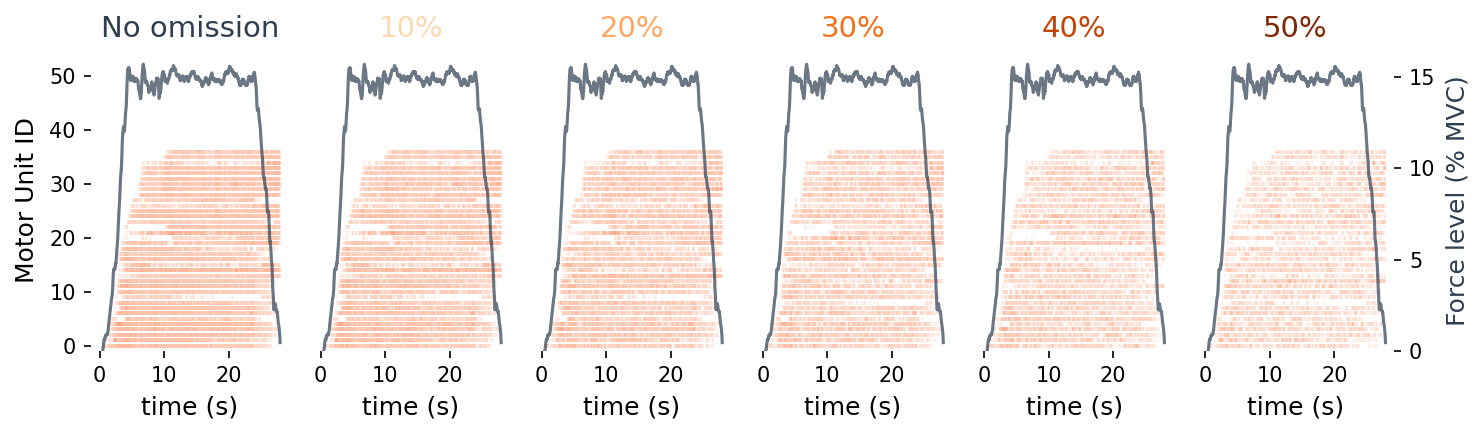

In [14]:
test_rep = 2
finger_task = 3
noise_levels = [0,10,20,30,40,50]
noise_mode = 'omission'
raster_plot_mu_across_noise_levels(prepared_snndata,
                                   flat_snn_config,
                                   data_config,
                                   test_rep,
                                   finger_task,                                            
                                   noise_mode,
                                   noise_levels,
                                   subject,
                                   save_fig=False,
                                   output_figures_dir=output_figures_dir)

# Visualize addition noise

finger_task_index_within_rep: 3, finger_sample_id: 8


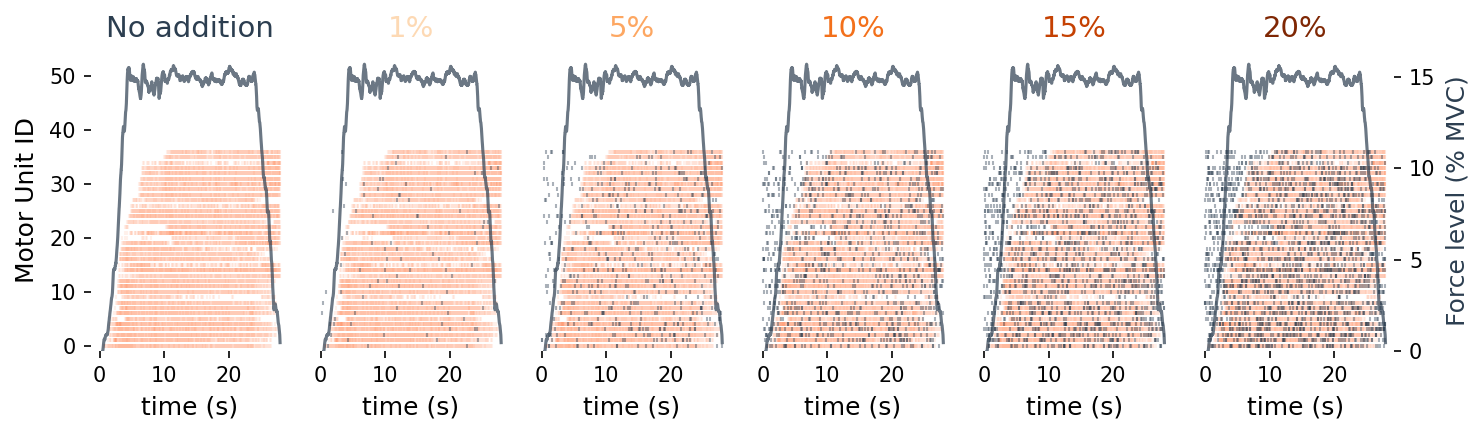

In [15]:
test_rep = 2
finger_task = 3
noise_levels = [0, 1, 5, 10, 15, 20]
noise_mode = 'addition'
raster_plot_mu_across_noise_levels(prepared_snndata,
                                   flat_snn_config,
                                   data_config,
                                   test_rep,
                                   finger_task,                                            
                                   noise_mode,
                                   noise_levels,
                                   subject,
                                   save_fig=False,
                                   output_figures_dir=output_figures_dir)

# Visualize location noise

finger_task_index_within_rep: 3, finger_sample_id: 8

Warning! the jitter applied is smaller than the simulation time step (0<0.01 ) and might be ineffective!


Warning! the jitter applied is smaller than the simulation time step (0.01<0.01 ) and might be ineffective!



/var/folders/1y/yxmkl7q925ngnqb0g8m6nw7h0000gn/T/ipykernel_76443/3907864909.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


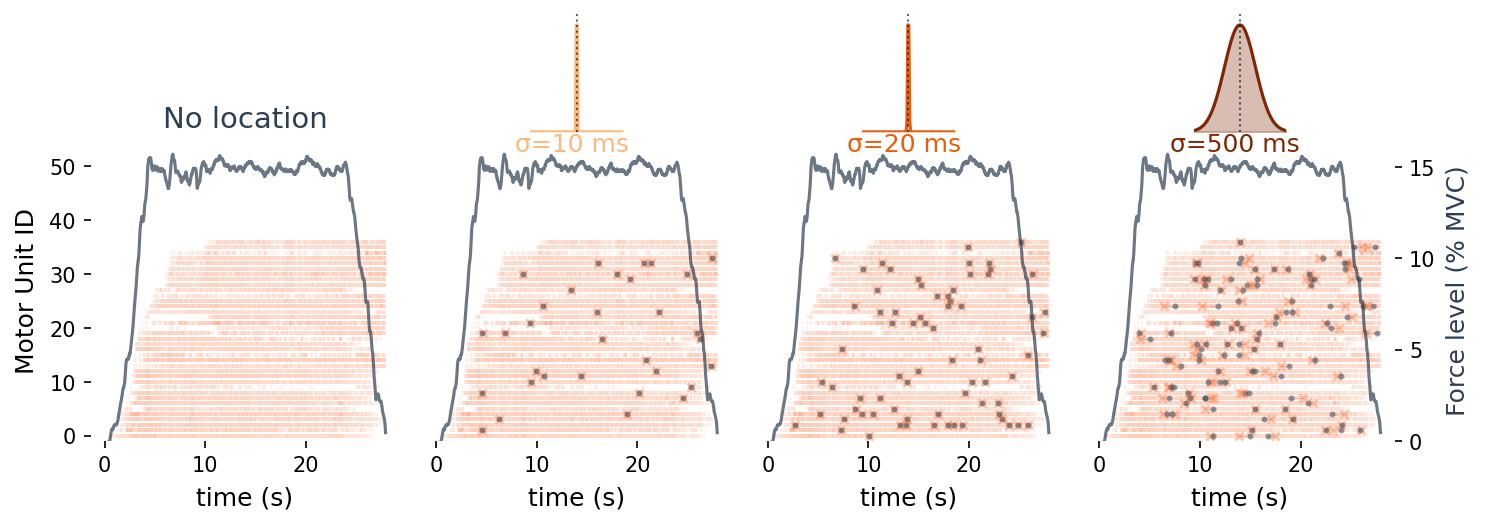

In [16]:
test_rep = 2
finger_task = 3
noise_levels = [0, 10e-3, 20e-3, 0.5]
noise_mode = 'location'
raster_plot_mu_across_noise_levels(prepared_snndata,
                                   flat_snn_config,
                                   data_config,
                                   test_rep,
                                   finger_task,                                            
                                   noise_mode,
                                   noise_levels,
                                   subject,
                                   rand_indices_ratio=0.01,
                                   save_fig=False, 
                                   output_figures_dir=output_figures_dir)

# Visualize misattribution noise

finger_task_index_within_rep: 3, finger_sample_id: 8


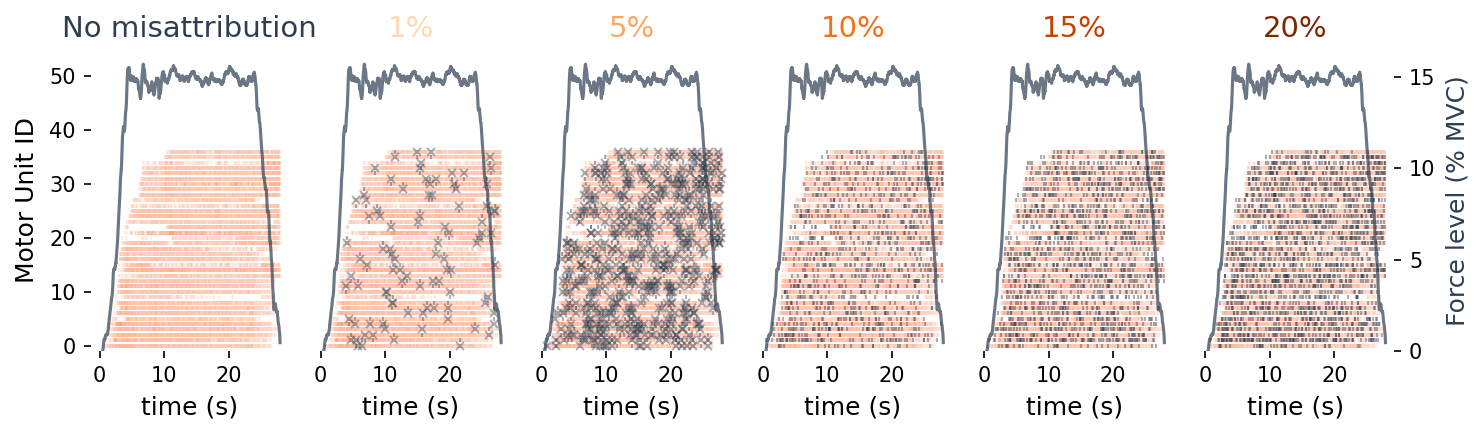

In [17]:
test_rep = 2
finger_task = 3
noise_levels = [0, 1, 5, 10, 15, 20]
noise_mode = 'misattribution'
raster_plot_mu_across_noise_levels(prepared_snndata,
                                   flat_snn_config,
                                   data_config,
                                   test_rep,
                                   finger_task,
                                   noise_mode,
                                   noise_levels,
                                   subject,
                                   save_fig=False, 
                                   output_figures_dir=output_figures_dir)